# 03 — Exploratory data analysis and graph topology

This studybook makes the dataset's imbalance, time variation, and network structure visible. It assumes the graph schema from notebook 00 and the evaluation timeline from notebook 01, but explains the topology vocabulary used here.

You will learn how to read class balance, temporal volume, node degree, heavy-tailed hubs, connected components, hybrid bridge companies, and anonymous ego graphs. All published outputs are aggregates or topology-only views without company names or financial row values.

## 1. EDA is part of model design

EDA is not a decorative prelude. Class imbalance determines metrics and loss weighting; time variation motivates temporal validation; degree concentration affects message aggregation; disconnected components limit where information can travel; and hybrids determine whether buyer→seller→buyer contagion paths exist.

In [1]:
from pathlib import Path

import pandas as pd

from graph_ml.data import GraphBuildConfig, build_trade_finance_graph
from graph_ml.viz import (
    anonymous_company_ego_graph,
    build_interactive_ego_network,
    class_balance_frame,
    company_degree_frame,
    component_size_frame,
    hybrid_footprint,
    plot_anonymous_ego_graph,
    plot_class_balance,
    plot_company_degree_distributions,
    plot_temporal_volume,
    temporal_volume_frame,
)

repo_root = next(
    parent for parent in (Path.cwd(), *Path.cwd().parents)
    if (parent / "pyproject.toml").exists()
)
instruments = pd.read_parquet(repo_root / "data/02_instrumentsdf_2.parquet")
graph_result = build_trade_finance_graph(
    instruments, GraphBuildConfig(cutoff="2018-04-30")
)
graph = graph_result.graph
graph

HeteroData(
  instrument={
    x=[59820, 12],
    y=[59820],
    node_id=[59820],
    invoice_date=[59820],
    pre_cutoff_mask=[59820],
  },
  company={
    x=[3349, 10],
    node_id=[3349],
  },
  (instrument, sold_by, company)={ edge_index=[2, 59820] },
  (company, sells, instrument)={ edge_index=[2, 59820] },
  (instrument, owed_by, company)={ edge_index=[2, 59820] },
  (company, owes, instrument)={ edge_index=[2, 59820] }
)

## 2. Class imbalance

Only about 2% of all instruments are impaired. A classifier predicting 'not impaired' for everything would be roughly 98% accurate, demonstrating why accuracy is unsuitable and why PR-AUC is the headline metric.

,outcome,count,share
0,not impaired,58588,97.94%
1,impaired,1232,2.06%


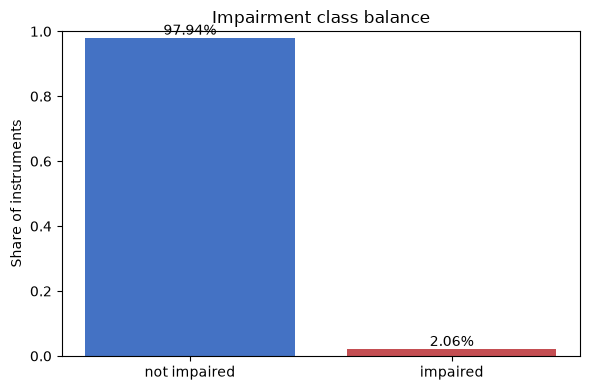

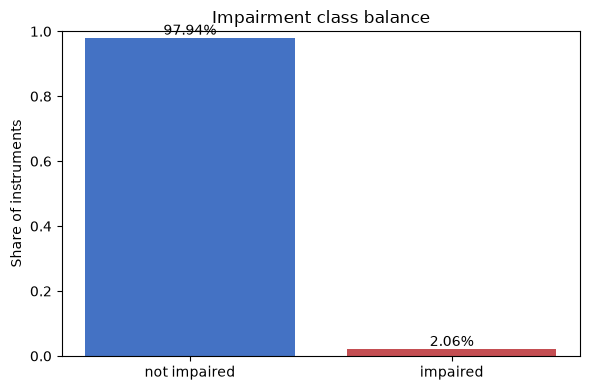

In [2]:
balance = class_balance_frame(graph["instrument"].y)
display(balance.style.format({"share": "{:.2%}"}))
plot_class_balance(balance)

## 3. The dataset is not stationary

A **stationary** data-generating process has stable statistical behavior over time. Here both transaction volume and impairment prevalence change substantially. This distribution shift is why random splitting gives an over-optimistic answer. Monthly aggregation reveals the pattern without publishing individual transactions.

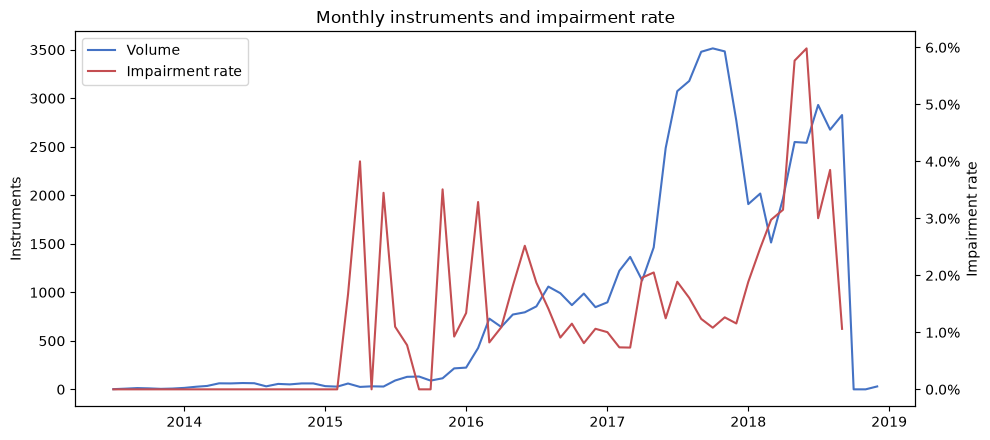

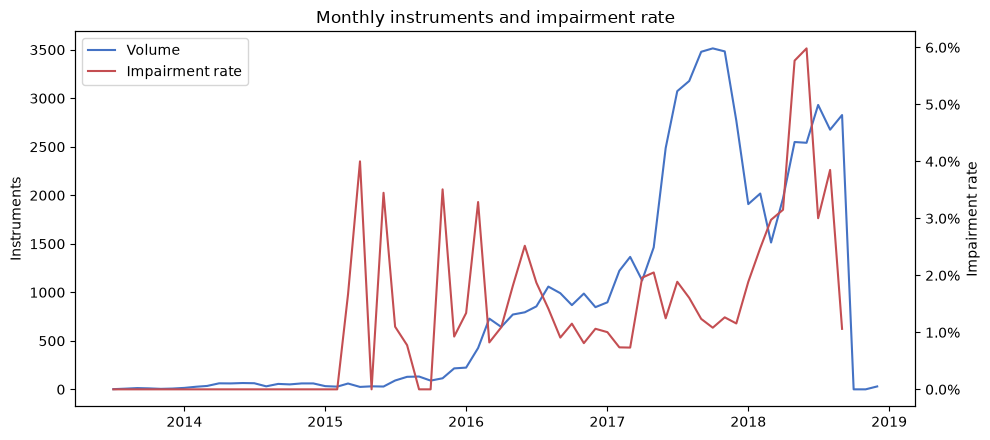

In [3]:
volume = temporal_volume_frame(
    instruments["invoice_date"], instruments["has_impairment1"]
)
plot_temporal_volume(volume)

## 4. Degree, hubs, and heavy tails

A node's **degree** is its number of incident edges. Here company seller-degree counts instruments sold by that company, while buyer-degree counts instruments it owes. Most companies have few instruments, but a handful are hubs with hundreds or thousands. This **heavy-tailed** distribution is shown on logarithmic axes; on linear axes the hubs would flatten almost everything else near zero.

High-degree companies can dominate sum aggregation and create very large receptive fields, so normalization will matter in the first GNN.

,seller_degree,buyer_degree,total_degree
count,3349.0,3349.0,3349.0
mean,17.9,17.9,35.7
std,205.1,61.0,212.6
min,0.0,0.0,1.0
50%,0.0,4.0,5.0
90%,0.0,34.0,42.0
99%,379.9,232.1,561.2
max,5636.0,1385.0,5636.0


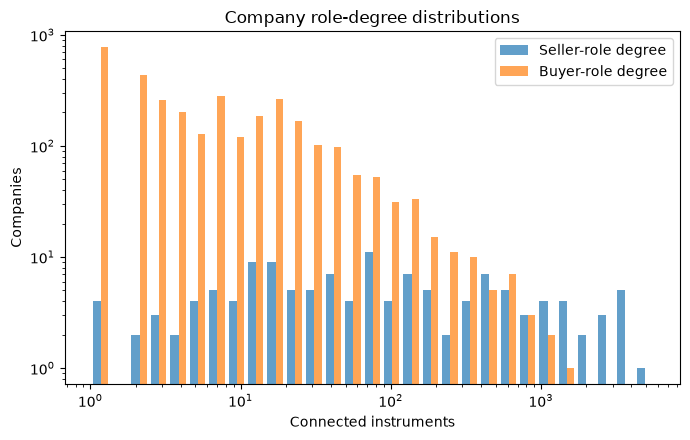

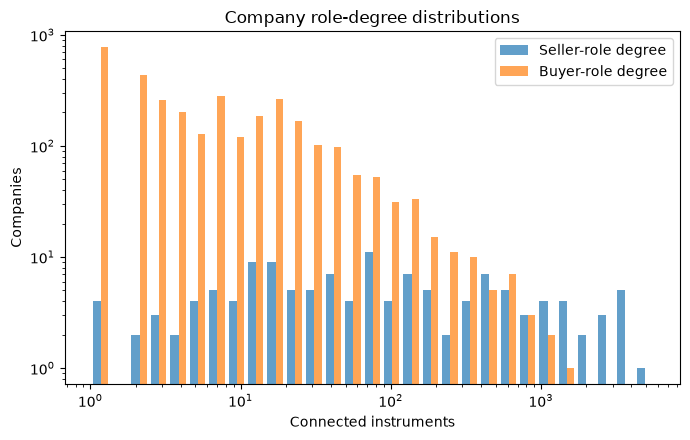

In [4]:
degrees = company_degree_frame(graph)
display(degrees[["seller_degree", "buyer_degree", "total_degree"]].describe(
    percentiles=[0.5, 0.9, 0.99]
).round(1))
plot_company_degree_distributions(degrees)

## 5. Connected components and hybrid bridges

A **connected component** is a maximal set of nodes joined by some path. Message passing cannot cross component boundaries. The filtered modelling graph has 45 components; the largest contains 81.6% of all nodes, so most—but not all—predictions live in one shared information system.

A **hybrid** company acts in both seller and buyer roles. Hybrids are the only companies that naturally bridge role directions across transactions, making them central to the later contagion hypothesis.

In [5]:
components = component_size_frame(graph)
footprint = hybrid_footprint(graph)
{
    "connected_components": len(components),
    "largest_component_node_share": (
        components.iloc[0]["total_nodes"] / components["total_nodes"].sum()
    ),
    **footprint,
}

{'connected_components': 45,
 'largest_component_node_share': np.float64(0.8155266032389304),
 'hybrid_companies': 15,
 'instruments_touching_hybrid': 12464,
 'instrument_share_touching_hybrid': 0.20835840855901036}

The 15 hybrids touch 12,464 of the 59,820 modelling instruments: 20.84%. The earlier 18.7% project statistic used 12,465 of the larger 66,593 pre-filter instrument table. Both are correct for their denominator; this notebook reports the graph actually modelled.

## 6. An ego graph makes local topology legible

An **ego graph** is the neighborhood around one focal node. The view below chooses the highest-degree hybrid, caps each role at twelve instruments, includes the counterpart company for each selected instrument, and removes all business labels. Red is the focal hybrid, blue nodes are other companies, orange nodes are instruments; green and purple edges distinguish seller and buyer roles.

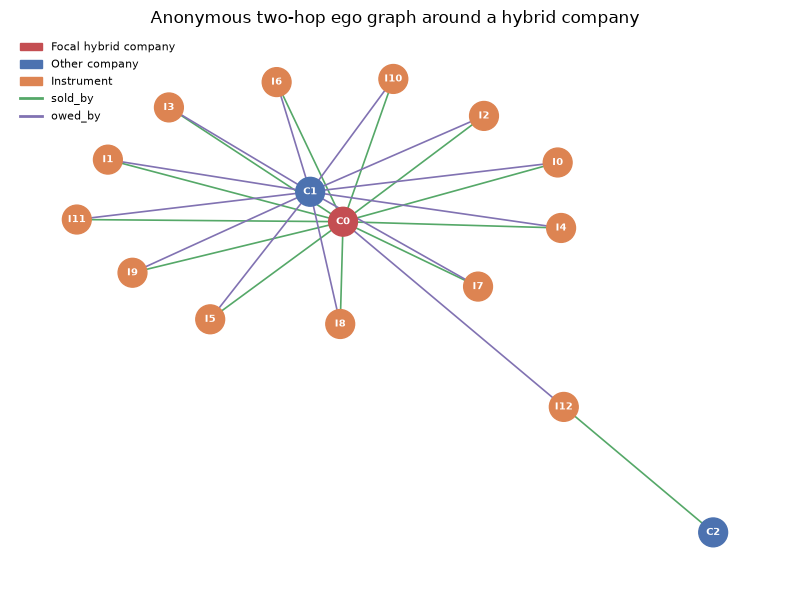

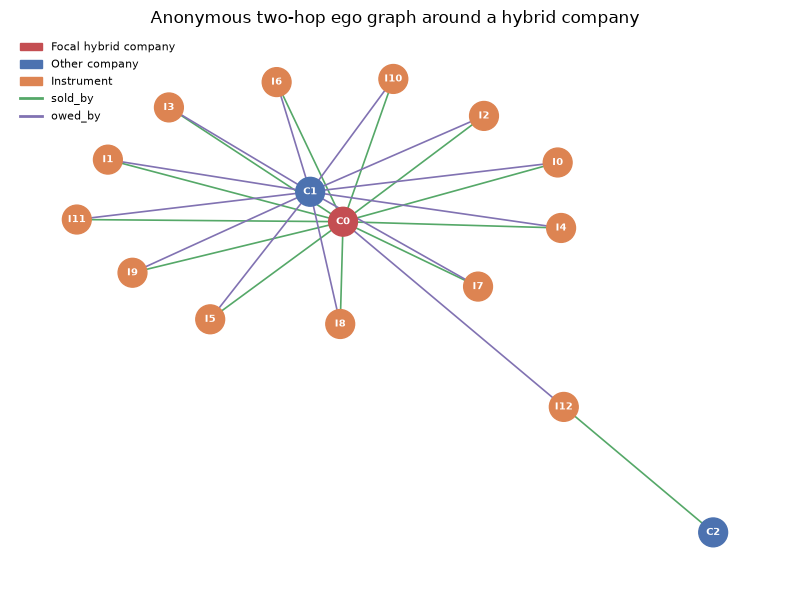

In [6]:
focal_company = int(
    degrees.loc[degrees["is_hybrid"]]
    .sort_values("total_degree", ascending=False)
    .iloc[0]["company_index"]
)
ego = anonymous_company_ego_graph(
    graph, focal_company, max_instruments_per_role=12
)
plot_anonymous_ego_graph(ego)

The same anonymous bounded graph can be converted to a draggable pyvis network. Large HTML is intentionally not committed; call `interactive.write_html('viz_exports/hybrid_ego.embed.html')` when local interaction is useful.

In [7]:
interactive = build_interactive_ego_network(ego)
{"interactive_nodes": len(interactive.nodes), "interactive_edges": len(interactive.edges)}

{'interactive_nodes': 16, 'interactive_edges': 26}

## Takeaways

- Severe imbalance makes accuracy misleading and motivates PR-AUC.
- Volume and impairment behavior change over time, reinforcing temporal evaluation.
- Company degrees are strongly heavy-tailed; hub normalization matters for message passing.
- The graph has 45 components, but 81.6% of nodes belong to the largest.
- Fifteen hybrids touch 20.84% of the filtered modelling instruments and form the key role bridges.
- Anonymous bounded ego graphs make local structure visible without publishing company identities or financial rows.